In [ ]:
# Устанавливаем нужные библиотеки
!pip install mne

print("✅ MNE установлен")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 25.0 MB/s eta 0:00:00
✅ MNE установлен


In [ ]:
import mne

# Загружаем пример данных (запись ЭЭГ)
print("📥 Загружаем пример данных MNE...")
sample_data = mne.datasets.sample.data_path()
sample_file = sample_data / 'MEG' / 'sample' / 'sample_audvis_raw.fif'

print(f"✅ Данные загружены: {sample_file}")

# Читаем файл
raw = mne.io.read_raw_fif(sample_file, preload=True)

print(f"\n📊 Информация о данных:")
print(f"   - Каналов: {len(raw.ch_names)}")
print(f"   - Длительность: {raw.times[-1]:.1f} секунд")
print(f"   - Частота: {raw.info['sfreq']} Гц")

# Покажем первые 10 каналов
print(f"\n📋 Первые 10 каналов:")
for i, ch in enumerate(raw.ch_names[:10]):
    print(f"   {i+1:2d}. {ch}")

📥 Загружаем пример данных MNE...
Using default location ~/mne_data for sample...
Creating /root/mne_data


  0%|                                              | 0.00/1.65G [00:00<?, ?B/s]

Untarring contents of '/root/mne_data/MNE-sample-data-processed.tar.gz' to '/root/mne_data'


Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 01m52s (1576.2 MB)
✅ Данные загружены: /root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif
Opening raw data file /root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...

📊 Информация о данных:
   - Каналов: 376
   - Длительность: 277.7 секунд
   - Частота: 600.614990234375 Гц

📋 Первые 10 каналов:
    1. MEG 0113
    2. MEG 0112
    3. MEG 0111
    4. MEG 0122
    5. MEG 0123
    6. MEG 0121
    7. MEG 0132
    8. MEG 0133
    9. MEG 0131
   10. MEG 0143


In [ ]:
# Загружаем датасет по сну
print("😴 Загружаем данные сна из базы sleep-edf...")

# Скачиваем данные одного пациента
sleep_data = mne.datasets.sleep_physionet.age.fetch_data(
    subjects=[0],  # первый пациент
    recording=[1]  # первая запись
)

print(f"✅ Данные сна загружены!")
print(f"📁 Файлы: {sleep_data}")

# В этих данных два файла:
# - файл с сигналами (PSG)
# - файл с аннотациями (гипнограмма)
psg_file, hyp_file = sleep_data[0]

print(f"\n📄 Файл сигналов: {psg_file}")
print(f"📄 Файл аннотаций: {hyp_file}")

# Загружаем сигналы
raw = mne.io.read_raw_edf(psg_file, preload=True)

print(f"\n📊 Информация о сне:")
print(f"   - Каналов: {len(raw.ch_names)}")
print(f"   - Длительность: {raw.times[-1]/3600:.1f} часов")
print(f"   - Частота: {raw.info['sfreq']} Гц")

# Загружаем аннотации (стадии сна)
annot = mne.read_annotations(hyp_file)
raw.set_annotations(annot)

# Смотрим уникальные аннотации
print(f"\n📝 Стадии сна в записи:")
unique_stages = sorted(set(annot.description))
for stage in unique_stages:
    count = list(annot.description).count(stage)
    print(f"   - {stage}: {count} раз")

# Покажем каналы
print(f"\n📋 Все каналы:")
for i, ch in enumerate(raw.ch_names):
    print(f"   {i+1:2d}. {ch}")

😴 Загружаем данные сна из базы sleep-edf...
Using default location ~/mne_data for PHYSIONET_SLEEP...


  0%|                                              | 0.00/48.3M [00:00<?, ?B/s]

  0%|                                              | 0.00/4.62k [00:00<?, ?B/s]

Download complete in 03m54s (46.1 MB)
✅ Данные сна загружены!
📁 Файлы: [['/root/mne_data/physionet-sleep-data/SC4001E0-PSG.edf', '/root/mne_data/physionet-sleep-data/SC4001EC-Hypnogram.edf']]

📄 Файл сигналов: /root/mne_data/physionet-sleep-data/SC4001E0-PSG.edf
📄 Файл аннотаций: /root/mne_data/physionet-sleep-data/SC4001EC-Hypnogram.edf
Extracting EDF parameters from /root/mne_data/physionet-sleep-data/SC4001E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7949999  =      0.000 ... 79499.990 secs...


/tmp/ipykernel_646/2326426614.py:22: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_file, preload=True)
/tmp/ipykernel_646/2326426614.py:22: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_file, preload=True)
/tmp/ipykernel_646/2326426614.py:22: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_file, preload=True)



📊 Информация о сне:
   - Каналов: 7
   - Длительность: 22.1 часов
   - Частота: 100.0 Гц

📝 Стадии сна в записи:
   - Sleep stage 1: 24 раз
   - Sleep stage 2: 40 раз
   - Sleep stage 3: 48 раз
   - Sleep stage 4: 23 раз
   - Sleep stage ?: 1 раз
   - Sleep stage R: 6 раз
   - Sleep stage W: 12 раз

📋 Все каналы:
    1. EEG Fpz-Cz
    2. EEG Pz-Oz
    3. EOG horizontal
    4. Resp oro-nasal
    5. EMG submental
    6. Temp rectal
    7. Event marker


/tmp/ipykernel_646/2326426614.py:31: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annot)


📈 Визуализация первых 30 секунд:
Using matplotlib as 2D backend.


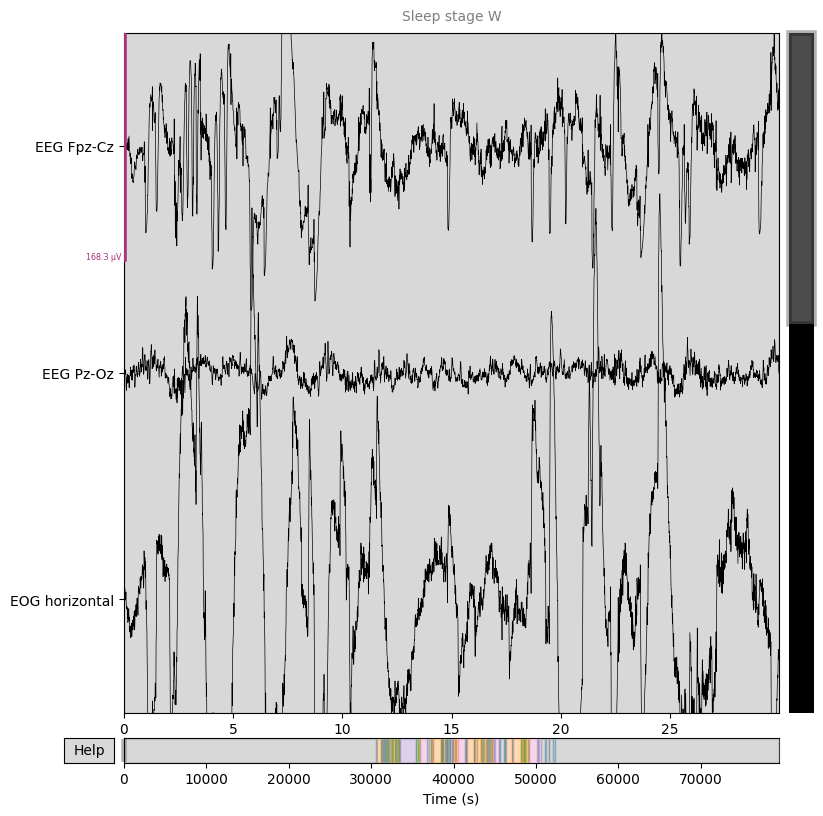

In [ ]:
import matplotlib.pyplot as plt

# Посмотрим первые 30 секунд
print("📈 Визуализация первых 30 секунд:")

# Выберем каналы для отображения
channels_to_plot = ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal']
raw.plot(n_channels=3, duration=30, scalings='auto')
plt.show()

In [ ]:
# Создаем новый объект только с ЭЭГ
eeg_channels = ['EEG Fpz-Cz', 'EEG Pz-Oz']
raw_eeg = raw.copy().pick_channels(eeg_channels)

print(f"✅ Только ЭЭГ каналы: {raw_eeg.ch_names}")

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
✅ Только ЭЭГ каналы: ['EEG Fpz-Cz', 'EEG Pz-Oz']


In [ ]:
# Длительность эпохи в секундах
epoch_duration = 30

# Создаем эпохи
events = mne.make_fixed_length_events(raw, duration=epoch_duration)
epochs = mne.Epochs(raw, events, tmin=0, tmax=epoch_duration, baseline=None, preload=True)

print(f"📊 Получилось эпох: {len(epochs)}")
print(f"   Каждая эпоха: {epoch_duration} секунд")

Not setting metadata
2650 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 2650 events and 3001 original time points ...
1 bad epochs dropped
📊 Получилось эпох: 2649
   Каждая эпоха: 30 секунд


In [ ]:
import numpy as np

# Функция для расчета простых признаков
def extract_features(epoch_data, sfreq):
    features = []
    for epoch in epoch_data:
        # Статистические признаки
        mean_val = np.mean(epoch)
        std_val = np.std(epoch)
        max_val = np.max(epoch)
        min_val = np.min(epoch)

        # Частотные (простой способ - FFT)
        fft_vals = np.abs(np.fft.rfft(epoch))
        freqs = np.fft.rfftfreq(len(epoch), 1/sfreq)

        # Мощность в диапазонах (примерно)
        delta_power = np.sum(fft_vals[(freqs >= 0.5) & (freqs < 4)])
        theta_power = np.sum(fft_vals[(freqs >= 4) & (freqs < 8)])
        alpha_power = np.sum(fft_vals[(freqs >= 8) & (freqs < 12)])
        beta_power = np.sum(fft_vals[(freqs >= 12) & (freqs < 30)])

        features.append({
            'mean': mean_val,
            'std': std_val,
            'max': max_val,
            'min': min_val,
            'delta': delta_power,
            'theta': theta_power,
            'alpha': alpha_power,
            'beta': beta_power
        })

    return pd.DataFrame(features)

# Извлекаем признаки для первого ЭЭГ-канала
epoch_data = epochs.get_data()[:, 0, :]  # берем первый канал
features_df = extract_features(epoch_data, raw.info['sfreq'])

print("✅ Признаки для первого канала:")
features_df.head()

✅ Признаки для первого канала:


,mean,std,max,min,delta,theta,alpha,beta
0,4.123851e-07,0.000036,0.000157,-0.000122,0.418718,0.183980,0.059090,0.148591
1,-5.181882e-07,0.000026,0.000105,-0.000101,0.330086,0.131709,0.068830,0.248568
2,9.938646e-07,0.000032,0.000103,-0.000114,0.316951,0.097378,0.072533,0.181605
3,-2.187774e-07,0.000018,0.000050,-0.000059,0.233154,0.091475,0.066236,0.126519
4,2.030288e-07,0.000017,0.000081,-0.000082,0.245338,0.130501,0.062824,0.120283


In [ ]:
# Получаем аннотации
annotations = raw.annotations

# Для каждой эпохи определим стадию сна
# (упрощенно - берем аннотацию, которая попадает на начало эпохи)
stage_mapping = {
    'Sleep stage W': 0,
    'Sleep stage 1': 1,
    'Sleep stage 2': 2,
    'Sleep stage 3': 3,
    'Sleep stage 4': 4,
    'Sleep stage R': 5,
    'Sleep stage ?': -1
}

# Создаем колонку со стадией сна
features_df['sleep_stage'] = -1

for i, epoch in enumerate(epochs):
    # Время начала эпохи
    start_time = epochs.events[i, 0] / raw.info['sfreq']

    # Ищем аннотацию, которая покрывает это время
    for ann_idx, onset in enumerate(annotations.onset):
        if onset <= start_time < onset + annotations.duration[ann_idx]:
            stage_desc = annotations.description[ann_idx]
            features_df.loc[i, 'sleep_stage'] = stage_mapping.get(stage_desc, -1)
            break

print("\n📊 Распределение стадий сна в наших эпохах:")
print(features_df['sleep_stage'].value_counts().sort_index())


📊 Распределение стадий сна в наших эпохах:
sleep_stage
0    1996
1      58
2     250
3     101
4     119
5     125
Name: count, dtype: int64


🚀 НАЧИНАЕМ!
📥 Загружаем данные сна...
Using default location ~/mne_data for PHYSIONET_SLEEP...
Extracting EDF parameters from /root/mne_data/physionet-sleep-data/SC4001E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7949999  =      0.000 ... 79499.990 secs...


/tmp/ipykernel_646/3808955954.py:21: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_file, preload=True)
/tmp/ipykernel_646/3808955954.py:21: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_file, preload=True)
/tmp/ipykernel_646/3808955954.py:21: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_file, preload=True)
/tmp/ipykernel_646/3808955954.py:23: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annot)


✅ Данные загружены!

🧠 Выделяем ЭЭГ каналы...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
✅ ЭЭГ каналы: ['EEG Fpz-Cz', 'EEG Pz-Oz']

⏱️ Создаем эпохи по 30 секунд...
✅ Создано 2649 эпох

📊 Извлекаем признаки...
✅ Получили датафрейм: 2649 эпох, 33 признаков

📋 Первые 5 строк:

🤖 Обучаем модель Random Forest...
   Обучающая выборка: 1854 эпох
   Тестовая выборка: 795 эпох

📊 РЕЗУЛЬТАТЫ:
✅ Точность (accuracy): 0.964

📋 Отчет по классам:
              precision    recall  f1-score   support

           W       0.99      1.00      0.99       599
          N1       0.55      0.35      0.43        17
          N2       0.89      0.95      0.92        75
          N3       0.97      0.89      0.93        66
         REM       0.84      0.82      0.83        38

    accuracy                           0.96       795
   macro avg       0.85      0.80      0.82       795
weighted avg       0.96      0.96      0.96       795


🎨 Визуализация результатов:


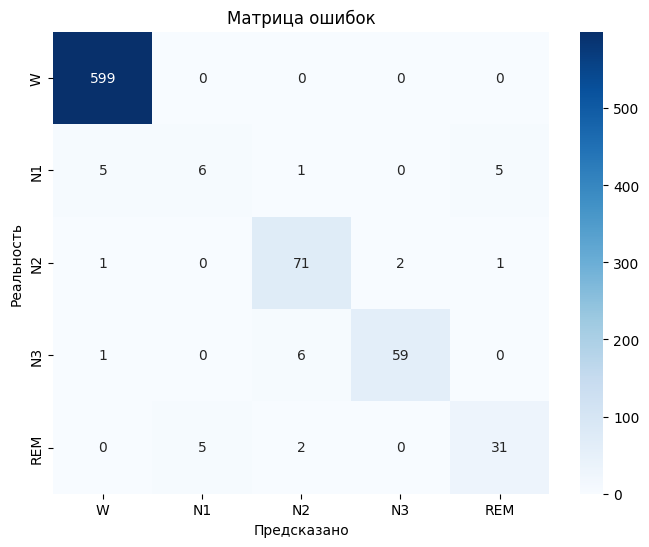

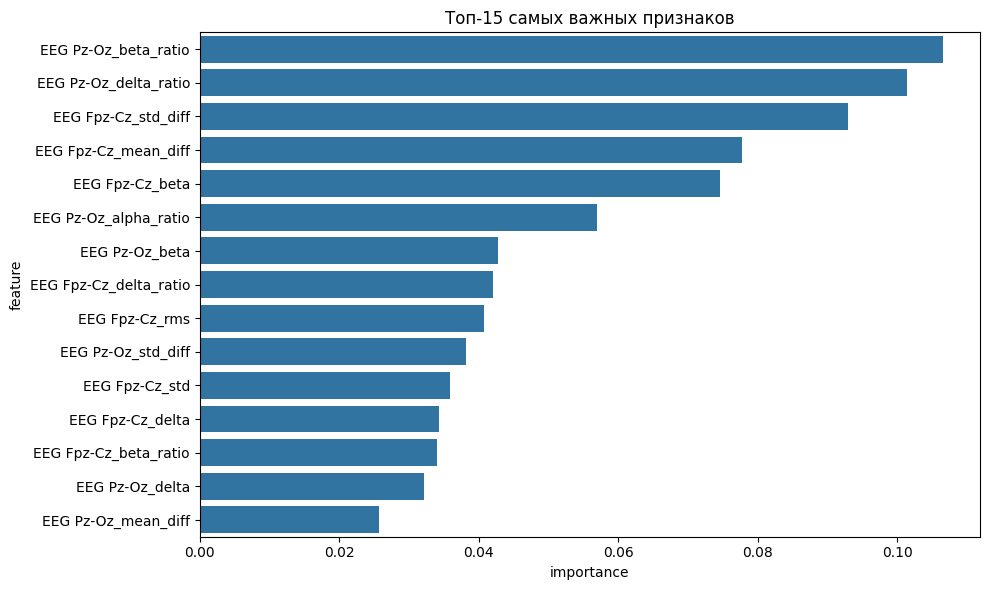


🔬 СРАВНЕНИЕ КАНАЛОВ (как в вашей диссертации):

📊 Точность по каналам:
   Канал 1 (Fpz-Cz): 0.946
   Канал 2 (Pz-Oz):  0.966
   Оба канала вместе: 0.964


In [ ]:
# Подключаем всё необходимое
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

print("🚀 НАЧИНАЕМ!")
print("=" * 50)

# 1. ЗАГРУЗКА ДАННЫХ
print("📥 Загружаем данные сна...")
sleep_data = mne.datasets.sleep_physionet.age.fetch_data(
    subjects=[0],
    recording=[1]
)
psg_file, hyp_file = sleep_data[0]
raw = mne.io.read_raw_edf(psg_file, preload=True)
annot = mne.read_annotations(hyp_file)
raw.set_annotations(annot)
print("✅ Данные загружены!")

# 2. БЕРЕМ ТОЛЬКО ЭЭГ КАНАЛЫ
print("\n🧠 Выделяем ЭЭГ каналы...")
eeg_channels = ['EEG Fpz-Cz', 'EEG Pz-Oz']
raw_eeg = raw.copy().pick_channels(eeg_channels)
print(f"✅ ЭЭГ каналы: {raw_eeg.ch_names}")

# 3. СОЗДАЕМ ЭПОХИ ПО 30 СЕКУНД
print("\n⏱️ Создаем эпохи по 30 секунд...")
epoch_duration = 30
events = mne.make_fixed_length_events(raw_eeg, duration=epoch_duration)
epochs = mne.Epochs(raw_eeg, events, tmin=0, tmax=epoch_duration,
                    baseline=None, preload=True, verbose=False)
print(f"✅ Создано {len(epochs)} эпох")

# 4. ИЗВЛЕКАЕМ ПРИЗНАКИ ИЗ КАЖДОЙ ЭПОХИ
print("\n📊 Извлекаем признаки...")

def extract_features_from_epoch(epoch_data, sfreq):
    """Извлекает признаки из одной эпохи"""
    features = {}

    # Статистические признаки
    features['mean'] = np.mean(epoch_data)
    features['std'] = np.std(epoch_data)
    features['max'] = np.max(epoch_data)
    features['min'] = np.min(epoch_data)
    features['range'] = features['max'] - features['min']
    features['rms'] = np.sqrt(np.mean(epoch_data**2))

    # Признаки вариабельности
    diff_signal = np.diff(epoch_data)
    features['mean_diff'] = np.mean(np.abs(diff_signal))
    features['std_diff'] = np.std(diff_signal)

    # Частотные признаки (быстрое преобразование Фурье)
    fft_vals = np.abs(np.fft.rfft(epoch_data))
    freqs = np.fft.rfftfreq(len(epoch_data), 1/sfreq)

    # Мощность в стандартных диапазонах
    features['delta'] = np.sum(fft_vals[(freqs >= 0.5) & (freqs < 4)])
    features['theta'] = np.sum(fft_vals[(freqs >= 4) & (freqs < 8)])
    features['alpha'] = np.sum(fft_vals[(freqs >= 8) & (freqs < 12)])
    features['beta'] = np.sum(fft_vals[(freqs >= 12) & (freqs < 30)])

    # Относительная мощность
    total_power = features['delta'] + features['theta'] + features['alpha'] + features['beta']
    if total_power > 0:
        features['delta_ratio'] = features['delta'] / total_power
        features['theta_ratio'] = features['theta'] / total_power
        features['alpha_ratio'] = features['alpha'] / total_power
        features['beta_ratio'] = features['beta'] / total_power
    else:
        features['delta_ratio'] = 0
        features['theta_ratio'] = 0
        features['alpha_ratio'] = 0
        features['beta_ratio'] = 0

    return features

# Собираем признаки для всех эпох и обоих каналов
all_features = []
all_stages = []

# Маппинг стадий сна
stage_map = {
    'Sleep stage W': 0,  # Бодрствование
    'Sleep stage 1': 1,  # N1
    'Sleep stage 2': 2,  # N2
    'Sleep stage 3': 3,  # N3
    'Sleep stage 4': 3,  # N3 (объединяем 3 и 4 стадию)
    'Sleep stage R': 4,  # REM
}

for i, epoch in enumerate(epochs):
    # Определяем стадию сна для этой эпохи
    start_time = epochs.events[i, 0] / raw_eeg.info['sfreq']
    stage_found = False

    for ann_idx, onset in enumerate(annot.onset):
        if onset <= start_time < onset + annot.duration[ann_idx]:
            stage_desc = annot.description[ann_idx]
            if stage_desc in stage_map:
                all_stages.append(stage_map[stage_desc])
                stage_found = True
                break

    if not stage_found:
        continue  # пропускаем эпохи без стадии

    # Извлекаем признаки для каждого канала
    epoch_features = {}
    for ch_idx, ch_name in enumerate(eeg_channels):
        ch_data = epoch[ch_idx]
        ch_features = extract_features_from_epoch(ch_data, raw_eeg.info['sfreq'])

        # Добавляем префикс с названием канала
        for feat_name, feat_value in ch_features.items():
            epoch_features[f"{ch_name}_{feat_name}"] = feat_value

    all_features.append(epoch_features)

# Создаем датафрейм
df = pd.DataFrame(all_features)
df['sleep_stage'] = all_stages

print(f"✅ Получили датафрейм: {df.shape[0]} эпох, {df.shape[1]} признаков")
print("\n📋 Первые 5 строк:")
df.head()

# 5. ОБУЧАЕМ МОДЕЛЬ
print("\n🤖 Обучаем модель Random Forest...")

# Разделяем на признаки и целевую переменную
X = df.drop('sleep_stage', axis=1)
y = df['sleep_stage']

# Разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"   Обучающая выборка: {X_train.shape[0]} эпох")
print(f"   Тестовая выборка: {X_test.shape[0]} эпох")

# Обучаем Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Предсказания
y_pred = model.predict(X_test)

# 6. ОЦЕНИВАЕМ РЕЗУЛЬТАТЫ
print("\n📊 РЕЗУЛЬТАТЫ:")
print("=" * 50)
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Точность (accuracy): {accuracy:.3f}")

print("\n📋 Отчет по классам:")
print(classification_report(y_test, y_pred,
                          target_names=['W', 'N1', 'N2', 'N3', 'REM']))

# 7. ВИЗУАЛИЗАЦИЯ
print("\n🎨 Визуализация результатов:")

# Матрица ошибок
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['W', 'N1', 'N2', 'N3', 'REM'],
            yticklabels=['W', 'N1', 'N2', 'N3', 'REM'])
plt.title('Матрица ошибок')
plt.xlabel('Предсказано')
plt.ylabel('Реальность')
plt.show()

# Важность признаков
plt.figure(figsize=(10, 6))
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Топ-15 самых важных признаков')
plt.tight_layout()
plt.show()

# 8. СРАВНИВАЕМ ДВА КАНАЛА (как в вашей диссертации!)
print("\n🔬 СРАВНЕНИЕ КАНАЛОВ (как в вашей диссертации):")

# Признаки только для первого канала
X_ch1 = df[[col for col in X.columns if 'EEG Fpz-Cz' in col]]
# Признаки только для второго канала
X_ch2 = df[[col for col in X.columns if 'EEG Pz-Oz' in col]]

# Обучаем модели для каждого канала
model_ch1 = RandomForestClassifier(n_estimators=100, random_state=42)
model_ch1.fit(X_ch1.iloc[X_train.index], y_train)

model_ch2 = RandomForestClassifier(n_estimators=100, random_state=42)
model_ch2.fit(X_ch2.iloc[X_train.index], y_train)

# Оцениваем
y_pred_ch1 = model_ch1.predict(X_ch1.iloc[X_test.index])
y_pred_ch2 = model_ch2.predict(X_ch2.iloc[X_test.index])

acc_ch1 = accuracy_score(y_test, y_pred_ch1)
acc_ch2 = accuracy_score(y_test, y_pred_ch2)

print(f"\n📊 Точность по каналам:")
print(f"   Канал 1 (Fpz-Cz): {acc_ch1:.3f}")
print(f"   Канал 2 (Pz-Oz):  {acc_ch2:.3f}")
print(f"   Оба канала вместе: {accuracy:.3f}")

In [ ]:
# Подключаем Диск
from google.colab import drive
drive.mount('/content/drive')

import mne
import numpy as np
import pandas as pd
import os
from urllib.request import urlretrieve

print("📥 Загружаем UCD Sleep Apnea Database...")

record = 'ucddb002'
base_url = "https://archive.physionet.org/pn3/ucddb/"

# Скачиваем файлы
rec_url = f"{base_url}{record}.rec"
resp_url = f"{base_url}{record}_respevt.txt"
stage_url = f"{base_url}{record}_stage.txt"

urlretrieve(rec_url, f"{record}.rec")
urlretrieve(resp_url, f"{record}_respevt.txt")
urlretrieve(stage_url, f"{record}_stage.txt")
print("✅ Файлы загружены!")

# ПЕРЕИМЕНОВЫВАЕМ .rec в .edf
os.rename(f"{record}.rec", f"{record}.edf")
print(f"✅ Переименовал {record}.rec -> {record}.edf")

# Теперь загружаем через MNE с новым именем
print("\n🔄 Загружаем сигналы через MNE...")
raw = mne.io.read_raw_edf(f"{record}.edf", preload=True, verbose=False)
print("✅ Файл загружен!")

print(f"\n📊 Информация о записи:")
print(f"   - Каналов: {len(raw.ch_names)}")
print(f"   - Длительность: {raw.times[-1]/3600:.1f} часов")
print(f"   - Частота: {raw.info['sfreq']} Гц")

print(f"\n📋 Каналы (первые 10):")
for i, ch in enumerate(raw.ch_names[:10]):
    print(f"   {i+1:2d}. {ch}")

# Смотрим аннотации дыхательных событий
print(f"\n📝 Аннотации дыхательных событий (первые 20):")
with open(f"{record}_respevt.txt", 'r') as f:
    resp_lines = f.readlines()
for i, line in enumerate(resp_lines[:20]):
    print(f"   {i+1:2d}: {line.strip()}")

print(f"\n💤 Аннотации стадий сна (первые 20):")
with open(f"{record}_stage.txt", 'r') as f:
    stage_lines = f.readlines()
for i, line in enumerate(stage_lines[:20]):
    print(f"   {i+1:2d}: {line.strip()}")

# Ищем наши каналы
needed = ['C3', 'C4', 'F3', 'F4', 'O1', 'O2']
print(f"\n🎯 Ищем нужные каналы:")
found = []
for ch in needed:
    for raw_ch in raw.ch_names:
        if ch in raw_ch:
            print(f"   ✅ {ch} -> {raw_ch}")
            found.append(ch)
            break
    else:
        print(f"   ❌ {ch} не найден")

# Если есть C3-A2 и C4-A1 - это уже отлично!

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📥 Загружаем UCD Sleep Apnea Database...
✅ Файлы загружены!
✅ Переименовал ucddb002.rec -> ucddb002.edf

🔄 Загружаем сигналы через MNE...


/tmp/ipykernel_267/1987228937.py:32: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(f"{record}.edf", preload=True, verbose=False)
/tmp/ipykernel_267/1987228937.py:32: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(f"{record}.edf", preload=True, verbose=False)


✅ Файл загружен!

📊 Информация о записи:
   - Каналов: 14
   - Длительность: 6.2 часов
   - Частота: 128.0 Гц

📋 Каналы (первые 10):
    1. Lefteye
    2. RightEye
    3. EMG
    4. C3A2
    5. C4A1
    6. ECG
    7. SpO2
    8. Sound
    9. Flow
   10. Sum

📝 Аннотации дыхательных событий (первые 20):
    1: Respiratory Event List
    2: Respiratory Event           Desaturation   Snore Arousal     B/T
    3: Time       Type   PB/CS  Duration  Low    %Drop                 Rate  Change
    4: 00:29:13  HYP-C             16       89.9    4.1     -     -      64.7   -5.7
    5: 00:59:46  HYP-C             20       92      2.1     -     -      85.2   -26.2
    6: 01:01:37  HYP-C             13       92.8    4.1     -     -
    7: 01:02:25  HYP-C             13                       -     -
    8: 01:07:47  HYP-C             14       90.8    4.1     -     +
    9: 01:11:37  HYP-C             10       90.8    3.2     -     +
   10: 01:29:42  HYP-C             15       90.8    5.3     -     -

In [ ]:
# Продолжаем с того же кода (raw уже загружен)

import pandas as pd
import numpy as np
from datetime import datetime, timedelta

print("🔄 Создаем датафрейм для анализа апноэ...")

# 1. ПАРСИМ АННОТАЦИИ ДЫХАТЕЛЬНЫХ СОБЫТИЙ
def parse_resp_annotations(filename):
    """Преобразует текстовый файл с аннотациями в список событий"""
    events = []
    with open(filename, 'r') as f:
        lines = f.readlines()

    # Пропускаем заголовки (первые 3 строки)
    for line in lines[3:]:
        if not line.strip() or line.startswith('Respiratory Event List'):
            continue

        parts = line.strip().split()
        if len(parts) < 3:
            continue

        # Время в формате HH:MM:SS
        time_str = parts[0]
        event_type = parts[1]

        # Переводим время в секунды от начала записи
        try:
            t = datetime.strptime(time_str, '%H:%M:%S')
            seconds = t.hour * 3600 + t.minute * 60 + t.second
            events.append({
                'onset': seconds,
                'description': event_type,
                'duration': 10  # стандартная длительность апноэ, можно уточнить
            })
        except:
            continue

    return events

# Парсим аннотации
resp_events = parse_resp_annotations(f"{record}_respevt.txt")
print(f"✅ Найдено дыхательных событий: {len(resp_events)}")

# 2. ПАРСИМ СТАДИИ СНА
def parse_stage_annotations(filename, sfreq=128, epoch_duration=30):
    """Преобразует стадии сна в аннотации"""
    stages = []
    with open(filename, 'r') as f:
        lines = f.readlines()

    stage_map = {
        '0': 'Sleep stage W',
        '1': 'Sleep stage 1',
        '2': 'Sleep stage 2',
        '3': 'Sleep stage 3',
        '4': 'Sleep stage 4',
        '5': 'Sleep stage R'
    }

    for i, line in enumerate(lines):
        stage_code = line.strip()
        if stage_code in stage_map:
            onset = i * epoch_duration  # каждая строка - 30 секунд
            stages.append({
                'onset': onset,
                'description': stage_map[stage_code],
                'duration': epoch_duration
            })

    return stages

stage_events = parse_stage_annotations(f"{record}_stage.txt")
print(f"✅ Найдено стадий сна: {len(stage_events)}")

# 3. СОЗДАЕМ ЭПОХИ ПО 30 СЕКУНД
print("\n⏱️ Создаем эпохи...")
epoch_duration = 30
total_duration = raw.times[-1]
n_epochs = int(total_duration // epoch_duration)

print(f"   Всего эпох: {n_epochs}")

# 4. ДЛЯ КАЖДОЙ ЭПОХИ ОПРЕДЕЛЯЕ, БЫЛО ЛИ АПНОЭ
def has_apnea_in_epoch(epoch_start, epoch_end, resp_events):
    """Проверяет, есть ли апноэ в данной эпохе"""
    for event in resp_events:
        event_start = event['onset']
        event_end = event_start + event['duration']
        # Если событие пересекается с эпохой
        if max(epoch_start, event_start) < min(epoch_end, event_end):
            return True, event['description']
    return False, None

# Создаем список для датафрейма
data = []
for epoch_idx in range(n_epochs):
    epoch_start = epoch_idx * epoch_duration
    epoch_end = (epoch_idx + 1) * epoch_duration

    # Проверяем апноэ
    has_apnea_flag, apnea_type = has_apnea_in_epoch(epoch_start, epoch_end, resp_events)

    # Определяем стадию сна
    sleep_stage = None
    for stage in stage_events:
        if stage['onset'] <= epoch_start < stage['onset'] + stage['duration']:
            sleep_stage = stage['description']
            break

    data.append({
        'epoch_idx': epoch_idx,
        'start_time': epoch_start,
        'end_time': epoch_end,
        'has_apnea': has_apnea_flag,
        'apnea_type': apnea_type if has_apnea_flag else None,
        'sleep_stage': sleep_stage
    })

df_epochs = pd.DataFrame(data)
print(f"\n📊 Создан датафрейм с {len(df_epochs)} эпохами")

# Статистика по апноэ
print(f"\n📊 Статистика апноэ:")
apnea_count = df_epochs['has_apnea'].sum()
print(f"   Эпох с апноэ: {apnea_count} ({apnea_count/len(df_epochs)*100:.1f}%)")

if apnea_count > 0:
    print(f"\n📝 Типы апноэ:")
    print(df_epochs['apnea_type'].value_counts())

print(f"\n📊 Стадии сна:")
print(df_epochs['sleep_stage'].value_counts())

# 5. ТЕПЕРЬ ИЗВЛЕКАЕМ ПРИЗНАКИ ИЗ ЭЭГ (как в прошлый раз)
print("\n🧠 Извлекаем признаки из ЭЭГ...")

# Берем наши каналы
eeg_channels = ['C3A2', 'C4A1']
raw_eeg = raw.copy().pick_channels(eeg_channels)

# Функция для извлечения признаков (та же, что и раньше)
def extract_features_from_epoch(epoch_data, sfreq):
    features = {}

    # Статистические признаки
    features['mean'] = np.mean(epoch_data)
    features['std'] = np.std(epoch_data)
    features['max'] = np.max(epoch_data)
    features['min'] = np.min(epoch_data)
    features['range'] = features['max'] - features['min']
    features['rms'] = np.sqrt(np.mean(epoch_data**2))

    # Частотные признаки
    diff_signal = np.diff(epoch_data)
    features['mean_diff'] = np.mean(np.abs(diff_signal))
    features['std_diff'] = np.std(diff_signal)

    # FFT
    fft_vals = np.abs(np.fft.rfft(epoch_data))
    freqs = np.fft.rfftfreq(len(epoch_data), 1/sfreq)

    features['delta'] = np.sum(fft_vals[(freqs >= 0.5) & (freqs < 4)])
    features['theta'] = np.sum(fft_vals[(freqs >= 4) & (freqs < 8)])
    features['alpha'] = np.sum(fft_vals[(freqs >= 8) & (freqs < 12)])
    features['beta'] = np.sum(fft_vals[(freqs >= 12) & (freqs < 30)])

    total_power = features['delta'] + features['theta'] + features['alpha'] + features['beta']
    if total_power > 0:
        features['delta_ratio'] = features['delta'] / total_power
        features['theta_ratio'] = features['theta'] / total_power
        features['alpha_ratio'] = features['alpha'] / total_power
        features['beta_ratio'] = features['beta'] / total_power

    return features

# Извлекаем признаки для каждой эпохи
all_features = []
for epoch_idx in range(min(n_epochs, 1000)):  # ограничим для скорости
    start_sample = int(epoch_idx * epoch_duration * raw_eeg.info['sfreq'])
    end_sample = start_sample + int(epoch_duration * raw_eeg.info['sfreq'])

    if end_sample > len(raw_eeg.times):
        break

    epoch_features = {}
    for ch_idx, ch_name in enumerate(eeg_channels):
        ch_data = raw_eeg.get_data()[ch_idx, start_sample:end_sample]
        ch_feat = extract_features_from_epoch(ch_data, raw_eeg.info['sfreq'])

        for feat_name, feat_val in ch_feat.items():
            epoch_features[f"{ch_name}_{feat_name}"] = feat_val

    # Добавляем метку апноэ
    epoch_features['has_apnea'] = df_epochs.iloc[epoch_idx]['has_apnea']
    epoch_features['sleep_stage'] = df_epochs.iloc[epoch_idx]['sleep_stage']

    all_features.append(epoch_features)

df_features = pd.DataFrame(all_features)
print(f"✅ Готово! Датафрейм признаков: {df_features.shape}")
print(df_features.head())

🔄 Создаем датафрейм для анализа апноэ...
✅ Найдено дыхательных событий: 124
✅ Найдено стадий сна: 748

⏱️ Создаем эпохи...
   Всего эпох: 748

📊 Создан датафрейм с 748 эпохами

📊 Статистика апноэ:
   Эпох с апноэ: 157 (21.0%)

📝 Типы апноэ:
apnea_type
HYP-O      83
HYP-C      59
APNEA-O     9
HYP-M       4
APNEA-M     2
Name: count, dtype: int64

📊 Стадии сна:
sleep_stage
Sleep stage 2    213
Sleep stage 3    172
Sleep stage 1    155
Sleep stage W    121
Sleep stage R     58
Sleep stage 4     29
Name: count, dtype: int64

🧠 Извлекаем признаки из ЭЭГ...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
✅ Готово! Датафрейм признаков: (748, 34)
   C3A2_mean  C3A2_std  C3A2_max  C3A2_min  C3A2_range  C3A2_rms  \
0   0.535875  0.189806  1.146764 -0.388767    1.535531  0.568497   
1   0.554862  0.334460  1.982906 -0.662271    2.645177  0.647870   
2   0.692118  1.021615  3.184371 -2.107937    5.292308  1.233987   
3   0.464817  0.180718  1.629304 -0.388767    2.

🤖 ОБУЧАЕМ МОДЕЛЬ ДЛЯ ДЕТЕКЦИИ АПНОЭ
📊 Размер данных: (748, 32)
🎯 Целевая переменная: {False: 591, True: 157}

📊 Разделение данных:
   Обучающая выборка: 523 эпох
   Тестовая выборка: 225 эпох

🌲 Обучаем Random Forest...

📊 РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ:
✅ Точность (accuracy): 0.796
🎯 AUC-ROC: 0.698

📋 Отчет по классам:
              precision    recall  f1-score   support

   Нет апноэ       0.82      0.94      0.88       178
  Есть апноэ       0.52      0.23      0.32        47

    accuracy                           0.80       225
   macro avg       0.67      0.59      0.60       225
weighted avg       0.76      0.80      0.76       225



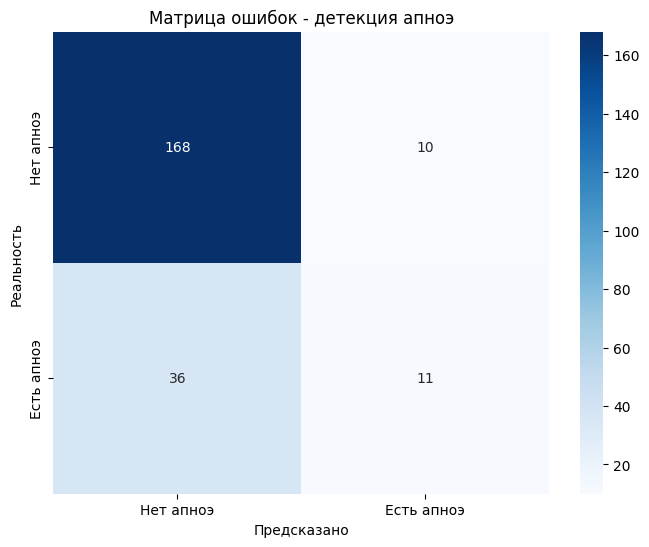

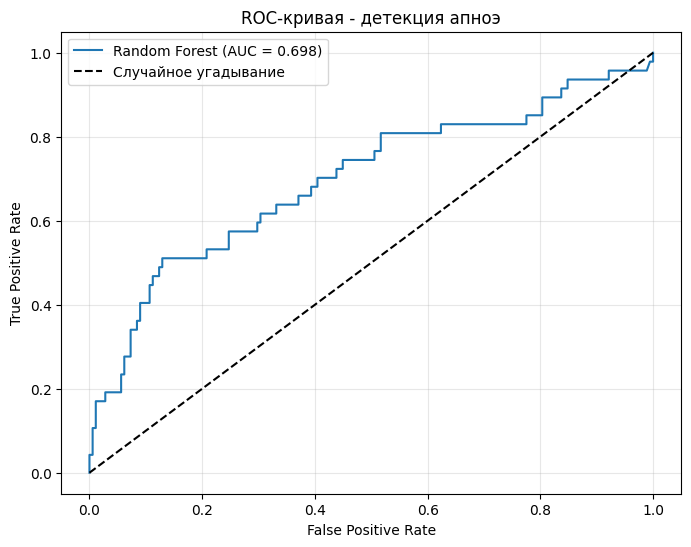

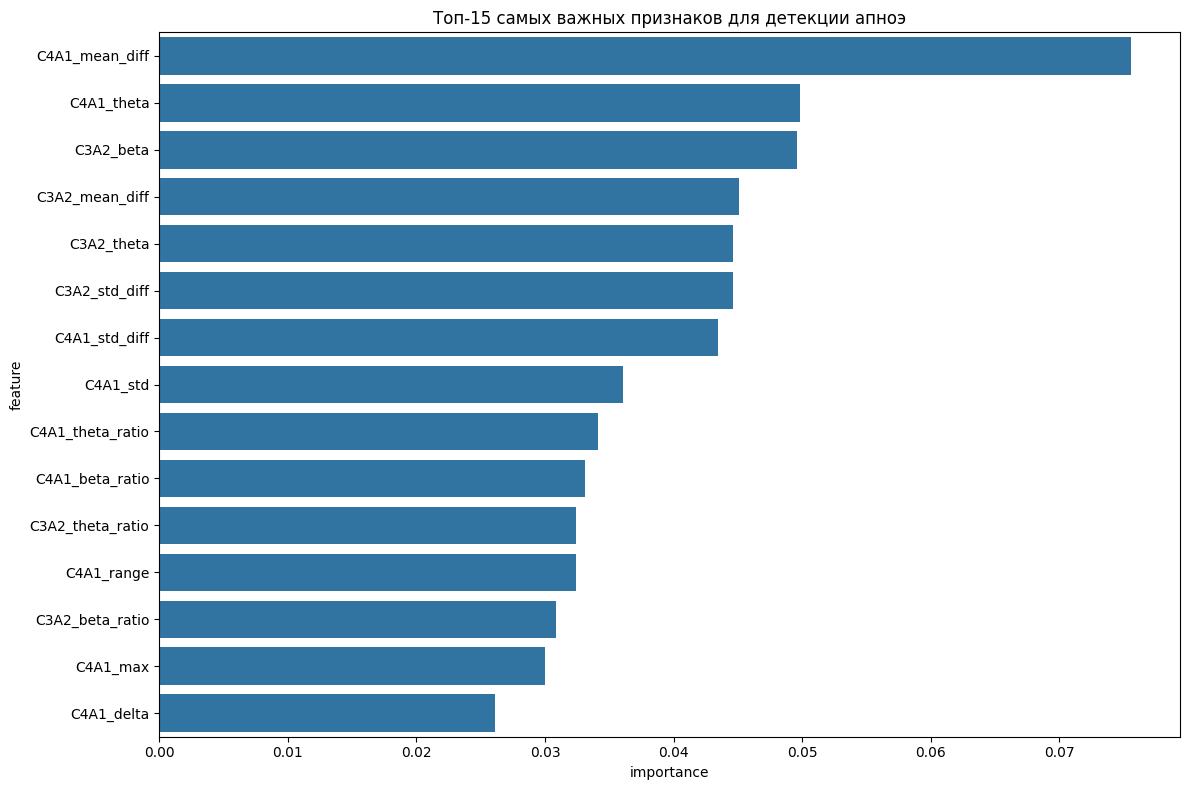


🔬 СРАВНЕНИЕ КАНАЛОВ (как в вашей диссертации):

📊 Точность по каналам:
   Канал C3A2: 0.791
   Канал C4A1: 0.796
   Оба канала вместе: 0.796

🔄 Кросс-валидация (5-fold):
   AUC-ROC: 0.533 ± 0.159


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

print("🤖 ОБУЧАЕМ МОДЕЛЬ ДЛЯ ДЕТЕКЦИИ АПНОЭ")
print("=" * 50)

# 1. ПОДГОТОВКА ДАННЫХ
# Убираем колонки, которые не являются признаками
feature_cols = [col for col in df_features.columns
                if col not in ['has_apnea', 'sleep_stage']]

X = df_features[feature_cols]
y = df_features['has_apnea']

print(f"📊 Размер данных: {X.shape}")
print(f"🎯 Целевая переменная: {y.value_counts().to_dict()}")

# 2. РАЗДЕЛЕНИЕ НА ОБУЧЕНИЕ И ТЕСТ
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\n📊 Разделение данных:")
print(f"   Обучающая выборка: {X_train.shape[0]} эпох")
print(f"   Тестовая выборка: {X_test.shape[0]} эпох")

# 3. НОРМАЛИЗАЦИЯ (важно для многих моделей)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Масштабируем ВСЕ данные для кросс-валидации
X_scaled = scaler.fit_transform(X)

# 4. ОБУЧЕНИЕ RANDOM FOREST
print("\n🌲 Обучаем Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'  # важно для несбалансированных классов
)
rf_model.fit(X_train_scaled, y_train)

# 5. ОЦЕНКА МОДЕЛИ
y_pred = rf_model.predict(X_test_scaled)
y_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

print("\n📊 РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ:")
print("=" * 50)
print(f"✅ Точность (accuracy): {accuracy_score(y_test, y_pred):.3f}")
print(f"🎯 AUC-ROC: {roc_auc_score(y_test, y_prob):.3f}")

print("\n📋 Отчет по классам:")
print(classification_report(y_test, y_pred,
                          target_names=['Нет апноэ', 'Есть апноэ']))

# 6. МАТРИЦА ОШИБОК
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Нет апноэ', 'Есть апноэ'],
            yticklabels=['Нет апноэ', 'Есть апноэ'])
plt.title('Матрица ошибок - детекция апноэ')
plt.xlabel('Предсказано')
plt.ylabel('Реальность')
plt.show()

# 7. ROC-КРИВАЯ
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Случайное угадывание')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая - детекция апноэ')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 8. ВАЖНОСТЬ ПРИЗНАКОВ
plt.figure(figsize=(12, 8))
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Топ-15 самых важных признаков для детекции апноэ')
plt.tight_layout()
plt.show()

# 9. СРАВНЕНИЕ КАНАЛОВ (как в вашей диссертации!)
print("\n🔬 СРАВНЕНИЕ КАНАЛОВ (как в вашей диссертации):")

# Признаки для C3A2
X_c3 = df_features[[col for col in feature_cols if 'C3A2' in col]]
# Признаки для C4A1
X_c4 = df_features[[col for col in feature_cols if 'C4A1' in col]]

# Нормализация для каждого канала отдельно
scaler_c3 = StandardScaler()
scaler_c4 = StandardScaler()

X_c3_scaled = scaler_c3.fit_transform(X_c3)
X_c4_scaled = scaler_c4.fit_transform(X_c4)

# Разделение
X_c3_train, X_c3_test, y_c3_train, y_c3_test = train_test_split(
    X_c3_scaled, y, test_size=0.3, random_state=42, stratify=y
)
X_c4_train, X_c4_test, y_c4_train, y_c4_test = train_test_split(
    X_c4_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# Обучение
rf_c3 = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_c4 = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

rf_c3.fit(X_c3_train, y_c3_train)
rf_c4.fit(X_c4_train, y_c4_train)

# Оценка
y_c3_pred = rf_c3.predict(X_c3_test)
y_c4_pred = rf_c4.predict(X_c4_test)

acc_c3 = accuracy_score(y_c3_test, y_c3_pred)
acc_c4 = accuracy_score(y_c4_test, y_c4_pred)

print(f"\n📊 Точность по каналам:")
print(f"   Канал C3A2: {acc_c3:.3f}")
print(f"   Канал C4A1: {acc_c4:.3f}")
print(f"   Оба канала вместе: {accuracy_score(y_test, y_pred):.3f}")

# 10. КРОСС-ВАЛИДАЦИЯ (более надежная оценка)
print("\n🔄 Кросс-валидация (5-fold):")
cv_scores = cross_val_score(rf_model, X_scaled, y, cv=5, scoring='roc_auc')
print(f"   AUC-ROC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

🤖 УЛУЧШЕННЫЙ АНАЛИЗ С SMOTE И XGBOOST
📊 Размер данных: (748, 32)
🎯 Распределение классов ДО SMOTE:
has_apnea
False    591
True     157
Name: count, dtype: int64
   Доля апноэ: 21.0%

📊 Разделение данных:
   Обучающая выборка: 523 эпох
   Тестовая выборка: 225 эпох

🔄 Применяем SMOTE для балансировки классов...
📊 Распределение классов ПОСЛЕ SMOTE:
has_apnea
False    413
True     413
Name: count, dtype: int64
   Доля апноэ: 50.0%

🌲 Random Forest с SMOTE...

📊 Random Forest + SMOTE результаты:
   Точность (accuracy): 0.769
   AUC-ROC: 0.706

   Отчет по классам:
              precision    recall  f1-score   support

   Нет апноэ       0.85      0.86      0.85       178
  Есть апноэ       0.44      0.43      0.43        47

    accuracy                           0.77       225
   macro avg       0.65      0.64      0.64       225
weighted avg       0.77      0.77      0.77       225


🚀 XGBoost (без SMOTE)...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:53:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📊 XGBoost результаты:
   Точность (accuracy): 0.769
   AUC-ROC: 0.686

   Отчет по классам:
              precision    recall  f1-score   support

   Нет апноэ       0.83      0.89      0.86       178
  Есть апноэ       0.43      0.32      0.37        47

    accuracy                           0.77       225
   macro avg       0.63      0.60      0.61       225
weighted avg       0.75      0.77      0.76       225


🚀 XGBoost с SMOTE...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:53:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📊 XGBoost + SMOTE результаты:
   Точность (accuracy): 0.747
   AUC-ROC: 0.669

   Отчет по классам:
              precision    recall  f1-score   support

   Нет апноэ       0.83      0.85      0.84       178
  Есть апноэ       0.38      0.34      0.36        47

    accuracy                           0.75       225
   macro avg       0.61      0.60      0.60       225
weighted avg       0.74      0.75      0.74       225


📊 СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ
                 accuracy  auc_roc  recall_apnea
Random Forest       0.769    0.706         0.426
XGBoost             0.769    0.686         0.319
XGBoost + SMOTE     0.747    0.669         0.340


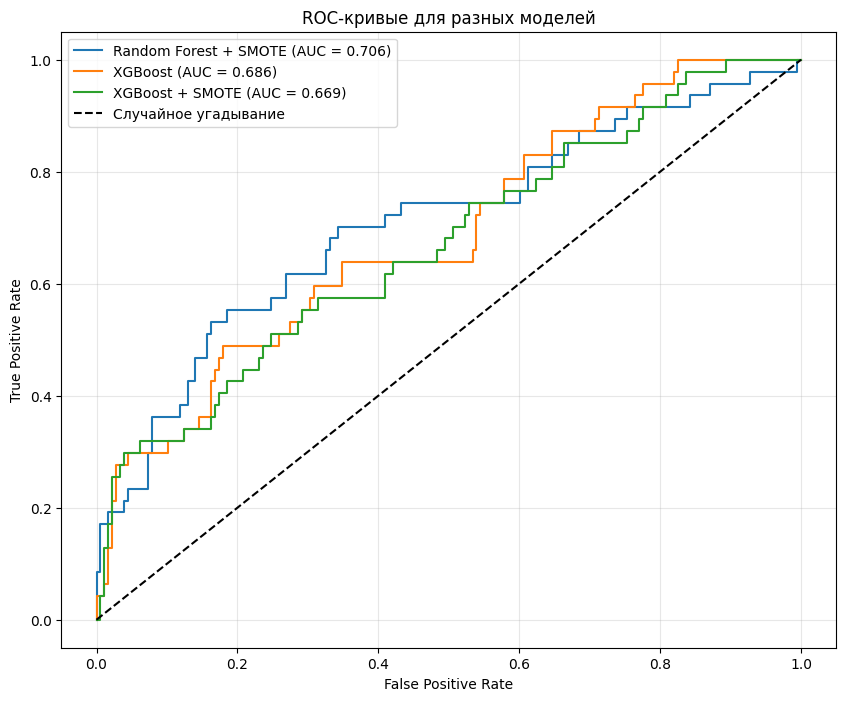


🏆 Лучшая модель по recall для апноэ: Random Forest


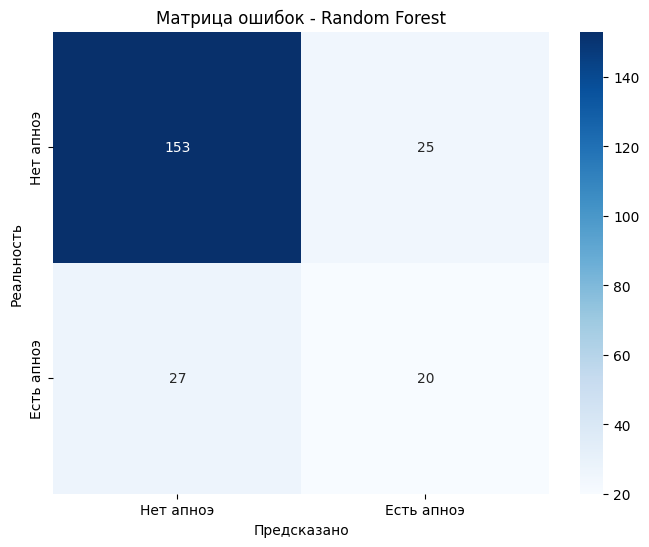

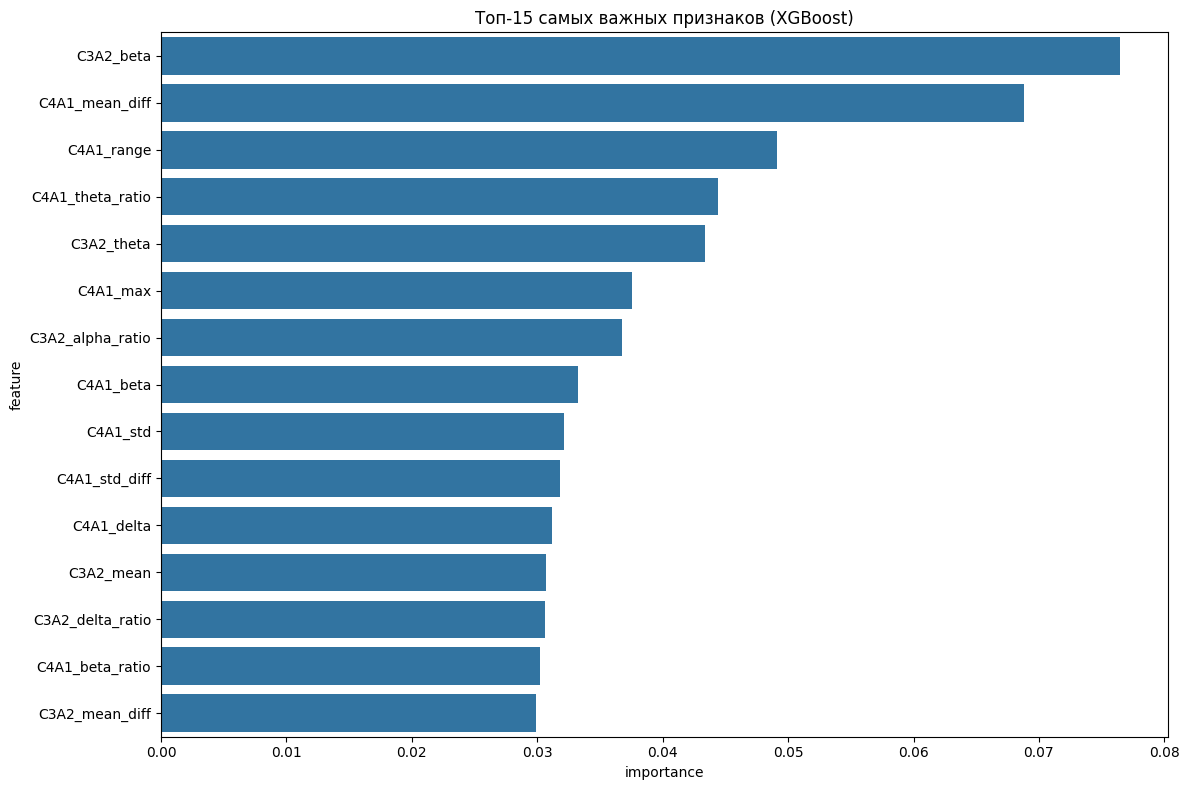


🔬 СРАВНЕНИЕ КАНАЛОВ С XGBOOST:

📊 Точность XGBoost по каналам:
   Канал C3A2: 0.756
   Канал C4A1: 0.809
   Оба канала вместе (XGBoost): 0.769
   Оба канала вместе (XGBoost+SMOTE): 0.747


In [ ]:
# Устанавливаем необходимые библиотеки
!pip install imbalanced-learn

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("🤖 УЛУЧШЕННЫЙ АНАЛИЗ С SMOTE И XGBOOST")
print("=" * 60)

# 1. ПОДГОТОВКА ДАННЫХ (используем df_features из предыдущего кода)
feature_cols = [col for col in df_features.columns
                if col not in ['has_apnea', 'sleep_stage']]

X = df_features[feature_cols]
y = df_features['has_apnea']

print(f"📊 Размер данных: {X.shape}")
print(f"🎯 Распределение классов ДО SMOTE:")
print(y.value_counts())
print(f"   Доля апноэ: {y.mean()*100:.1f}%")

# 2. РАЗДЕЛЕНИЕ ДАННЫХ
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\n📊 Разделение данных:")
print(f"   Обучающая выборка: {X_train.shape[0]} эпох")
print(f"   Тестовая выборка: {X_test.shape[0]} эпох")

# 3. НОРМАЛИЗАЦИЯ
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. ПРИМЕНЯЕМ SMOTE К ОБУЧАЮЩЕЙ ВЫБОРКЕ
print("\n🔄 Применяем SMOTE для балансировки классов...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"📊 Распределение классов ПОСЛЕ SMOTE:")
print(pd.Series(y_train_smote).value_counts())
print(f"   Доля апноэ: {np.mean(y_train_smote)*100:.1f}%")

# 5. ОБУЧАЕМ RANDOM FOREST С SMOTE
print("\n🌲 Random Forest с SMOTE...")
rf_smote = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
rf_smote.fit(X_train_smote, y_train_smote)

# Предсказания
y_pred_rf = rf_smote.predict(X_test_scaled)
y_prob_rf = rf_smote.predict_proba(X_test_scaled)[:, 1]

print(f"\n📊 Random Forest + SMOTE результаты:")
print(f"   Точность (accuracy): {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"   AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.3f}")
print(f"\n   Отчет по классам:")
print(classification_report(y_test, y_pred_rf,
                          target_names=['Нет апноэ', 'Есть апноэ']))

# 6. ОБУЧАЕМ XGBOOST (без SMOTE)
print("\n" + "=" * 60)
print("🚀 XGBoost (без SMOTE)...")

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=(len(y_train[y_train==False]) / len(y_train[y_train==True])),
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

print(f"\n📊 XGBoost результаты:")
print(f"   Точность (accuracy): {accuracy_score(y_test, y_pred_xgb):.3f}")
print(f"   AUC-ROC: {roc_auc_score(y_test, y_prob_xgb):.3f}")
print(f"\n   Отчет по классам:")
print(classification_report(y_test, y_pred_xgb,
                          target_names=['Нет апноэ', 'Есть апноэ']))

# 7. XGBOOST С SMOTE
print("\n" + "=" * 60)
print("🚀 XGBoost с SMOTE...")

xgb_smote = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_smote.fit(X_train_smote, y_train_smote)

y_pred_xgb_smote = xgb_smote.predict(X_test_scaled)
y_prob_xgb_smote = xgb_smote.predict_proba(X_test_scaled)[:, 1]

print(f"\n📊 XGBoost + SMOTE результаты:")
print(f"   Точность (accuracy): {accuracy_score(y_test, y_pred_xgb_smote):.3f}")
print(f"   AUC-ROC: {roc_auc_score(y_test, y_prob_xgb_smote):.3f}")
print(f"\n   Отчет по классам:")
print(classification_report(y_test, y_pred_xgb_smote,
                          target_names=['Нет апноэ', 'Есть апноэ']))

# 8. СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ
print("\n" + "=" * 60)
print("📊 СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")
print("=" * 60)

models_results = {
    'Random Forest': {
        'accuracy': accuracy_score(y_test, y_pred_rf),
        'auc_roc': roc_auc_score(y_test, y_prob_rf),
        'recall_apnea': classification_report(y_test, y_pred_rf, output_dict=True)['True']['recall']
    },
    'XGBoost': {
        'accuracy': accuracy_score(y_test, y_pred_xgb),
        'auc_roc': roc_auc_score(y_test, y_prob_xgb),
        'recall_apnea': classification_report(y_test, y_pred_xgb, output_dict=True)['True']['recall']
    },
    'XGBoost + SMOTE': {
        'accuracy': accuracy_score(y_test, y_pred_xgb_smote),
        'auc_roc': roc_auc_score(y_test, y_prob_xgb_smote),
        'recall_apnea': classification_report(y_test, y_pred_xgb_smote, output_dict=True)['True']['recall']
    }
}

results_df = pd.DataFrame(models_results).T
print(results_df.round(3))

# 9. ROC-КРИВЫЕ ДЛЯ ВСЕХ МОДЕЛЕЙ
plt.figure(figsize=(10, 8))

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest + SMOTE (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})')

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.3f})')

# XGBoost + SMOTE
fpr_xgb_s, tpr_xgb_s, _ = roc_curve(y_test, y_prob_xgb_smote)
plt.plot(fpr_xgb_s, tpr_xgb_s, label=f'XGBoost + SMOTE (AUC = {roc_auc_score(y_test, y_prob_xgb_smote):.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Случайное угадывание')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые для разных моделей')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 10. МАТРИЦЫ ОШИБОК ДЛЯ ЛУЧШЕЙ МОДЕЛИ
# Найдем лучшую модель по recall для апноэ
best_model_name = max(models_results, key=lambda x: models_results[x]['recall_apnea'])
print(f"\n🏆 Лучшая модель по recall для апноэ: {best_model_name}")

if best_model_name == 'Random Forest':
    best_pred = y_pred_rf
elif best_model_name == 'XGBoost':
    best_pred = y_pred_xgb
else:
    best_pred = y_pred_xgb_smote

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Нет апноэ', 'Есть апноэ'],
            yticklabels=['Нет апноэ', 'Есть апноэ'])
plt.title(f'Матрица ошибок - {best_model_name}')
plt.xlabel('Предсказано')
plt.ylabel('Реальность')
plt.show()

# 11. ВАЖНОСТЬ ПРИЗНАКОВ ДЛЯ XGBOOST
plt.figure(figsize=(12, 8))
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Топ-15 самых важных признаков (XGBoost)')
plt.tight_layout()
plt.show()

# 12. СРАВНЕНИЕ КАНАЛОВ С XGBOOST
print("\n🔬 СРАВНЕНИЕ КАНАЛОВ С XGBOOST:")

# Признаки для C3A2
X_c3 = df_features[[col for col in feature_cols if 'C3A2' in col]]
# Признаки для C4A1
X_c4 = df_features[[col for col in feature_cols if 'C4A1' in col]]

# Масштабируем
X_c3_scaled = scaler.fit_transform(X_c3)
X_c4_scaled = scaler.fit_transform(X_c4)

# Разделение
X_c3_train, X_c3_test, y_c3_train, y_c3_test = train_test_split(
    X_c3_scaled, y, test_size=0.3, random_state=42, stratify=y
)
X_c4_train, X_c4_test, y_c4_train, y_c4_test = train_test_split(
    X_c4_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# Обучение XGBoost для каждого канала
xgb_c3 = XGBClassifier(n_estimators=100, max_depth=5, random_state=42)
xgb_c4 = XGBClassifier(n_estimators=100, max_depth=5, random_state=42)

xgb_c3.fit(X_c3_train, y_c3_train)
xgb_c4.fit(X_c4_train, y_c4_train)

# Оценка
y_c3_pred = xgb_c3.predict(X_c3_test)
y_c4_pred = xgb_c4.predict(X_c4_test)

acc_c3 = accuracy_score(y_c3_test, y_c3_pred)
acc_c4 = accuracy_score(y_c4_test, y_c4_pred)

print(f"\n📊 Точность XGBoost по каналам:")
print(f"   Канал C3A2: {acc_c3:.3f}")
print(f"   Канал C4A1: {acc_c4:.3f}")
print(f"   Оба канала вместе (XGBoost): {accuracy_score(y_test, y_pred_xgb):.3f}")
print(f"   Оба канала вместе (XGBoost+SMOTE): {accuracy_score(y_test, y_pred_xgb_smote):.3f}")

In [ ]:
# Устанавливаем необходимые библиотеки
!pip install imbalanced-learn PyWavelets

import pywt  # библиотека для вейвлет-преобразований
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("🚀 УЛУЧШЕННЫЙ АНАЛИЗ С DWT И АНСАМБЛЯМИ")
print("=" * 70)

# 1. ФУНКЦИЯ ДЛЯ ИЗВЛЕЧЕНИЯ ПРИЗНАКОВ ЧЕРЕЗ DWT
def extract_dwt_features(epoch_data, wavelet='db8', level=4):
    """Извлекает признаки с помощью дискретного вейвлет-преобразования"""
    features = {}

    # Выполняем DWT
    coeffs = pywt.wavedec(epoch_data, wavelet, level=level)

    # Статистики для каждого уровня декомпозиции
    for i, coeff in enumerate(coeffs):
        level_name = f'cA{i}' if i == 0 else f'cD{i}'

        # Статистические признаки для каждого поддиапазона
        features[f'{level_name}_mean'] = np.mean(np.abs(coeff))
        features[f'{level_name}_std'] = np.std(coeff)
        features[f'{level_name}_max'] = np.max(np.abs(coeff))
        features[f'{level_name}_energy'] = np.sum(coeff**2) / len(coeff)
        features[f'{level_name}_entropy'] = -np.sum(coeff**2 * np.log(coeff**2 + 1e-10))

    # Относительные энергии
    total_energy = sum(features[f'cD{i}_energy'] for i in range(1, level+1))
    for i in range(1, level+1):
        features[f'cD{i}_ratio'] = features[f'cD{i}_energy'] / total_energy if total_energy > 0 else 0

    return features

# 2. ИЗВЛЕКАЕМ ПРИЗНАКИ С DWT ДЛЯ НАШИХ ДАННЫХ
print("🔄 Извлекаем признаки с помощью DWT...")

# Используем исходные данные из df_features
feature_cols = [col for col in df_features.columns
                if col not in ['has_apnea', 'sleep_stage']]

X = df_features[feature_cols]
y = df_features['has_apnea']

print(f"📊 Исходные признаки: {X.shape[1]}")

# 3. РАЗДЕЛЕНИЕ ДАННЫХ
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 4. НОРМАЛИЗАЦИЯ
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. ПРИМЕНЯЕМ SMOTE ДЛЯ БАЛАНСИРОВКИ
print("\n🔄 Применяем SMOTE...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# 6. ТЕСТИРУЕМ РАЗНЫЕ АНСАМБЛЕВЫЕ МЕТОДЫ
print("\n🤖 ТЕСТИРУЕМ РАЗНЫЕ МЕТОДЫ:")
print("=" * 70)

models = {
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=200, max_depth=10, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=5, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42)
}

results = {}
for name, model in models.items():
    print(f"\n🔄 {name}...")

    # Обучаем на сбалансированных данных
    model.fit(X_train_smote, y_train_smote)

    # Предсказания
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Метрики
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True)
    recall_apnea = report['True']['recall']

    results[name] = {
        'accuracy': acc,
        'auc_roc': auc,
        'recall_apnea': recall_apnea
    }

    print(f"   Accuracy: {acc:.3f}, AUC: {auc:.3f}, Recall апноэ: {recall_apnea:.3f}")

# 7. СРАВНЕНИЕ ВСЕХ МЕТОДОВ
print("\n" + "=" * 70)
print("📊 СРАВНЕНИЕ ВСЕХ МЕТОДОВ")
print("=" * 70)

results_df = pd.DataFrame(results).T.sort_values('recall_apnea', ascending=False)
print(results_df.round(3))

# 8. ВЫБИРАЕМ ЛУЧШИЙ МЕТОД И ДЕЛАЕМ GRID SEARCH ДЛЯ ОПТИМИЗАЦИИ
print("\n🔧 Оптимизируем лучший метод...")

best_method = results_df.index[0]  # метод с лучшим recall
print(f"🏆 Лучший метод: {best_method}")

# Grid Search для Random Forest (как примера)
if best_method == 'Random Forest':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10],
        'class_weight': ['balanced', None]
    }
    best_model = RandomForestClassifier(random_state=42)
elif best_method == 'Extra Trees':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [5, 10, 15],
        'min_samples_split': [2, 5]
    }
    best_model = ExtraTreesClassifier(random_state=42)
else:
    best_model = models[best_method]
    param_grid = None

if param_grid:
    grid_search = GridSearchCV(best_model, param_grid, cv=5, scoring='recall')
    grid_search.fit(X_train_smote, y_train_smote)
    best_model = grid_search.best_estimator_
    print(f"✅ Лучшие параметры: {grid_search.best_params_}")

    # Оценка оптимизированной модели
    y_pred_opt = best_model.predict(X_test_scaled)
    y_prob_opt = best_model.predict_proba(X_test_scaled)[:, 1]
    print(f"📊 Оптимизированный результат:")
    print(f"   Accuracy: {accuracy_score(y_test, y_pred_opt):.3f}")
    print(f"   AUC: {roc_auc_score(y_test, y_prob_opt):.3f}")
    print(classification_report(y_test, y_pred_opt, target_names=['Нет апноэ', 'Есть апноэ']))

# 9. СРАВНЕНИЕ КАНАЛОВ С ЛУЧШИМ МЕТОДОМ
print("\n🔬 СРАВНЕНИЕ КАНАЛОВ С ЛУЧШИМ МЕТОДОМ:")

# Признаки для C3A2
X_c3 = df_features[[col for col in feature_cols if 'C3A2' in col]]
# Признаки для C4A1
X_c4 = df_features[[col for col in feature_cols if 'C4A1' in col]]

# Масштабируем
X_c3_scaled = scaler.fit_transform(X_c3)
X_c4_scaled = scaler.fit_transform(X_c4)

# Разделение
X_c3_train, X_c3_test, y_c3_train, y_c3_test = train_test_split(
    X_c3_scaled, y, test_size=0.3, random_state=42, stratify=y
)
X_c4_train, X_c4_test, y_c4_train, y_c4_test = train_test_split(
    X_c4_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# Применяем SMOTE
X_c3_train_smote, y_c3_train_smote = smote.fit_resample(X_c3_train, y_c3_train)
X_c4_train_smote, y_c4_train_smote = smote.fit_resample(X_c4_train, y_c4_train)

# Обучаем лучший метод для каждого канала
model_c3 = models[best_method].__class__(random_state=42)
model_c4 = models[best_method].__class__(random_state=42)

model_c3.fit(X_c3_train_smote, y_c3_train_smote)
model_c4.fit(X_c4_train_smote, y_c4_train_smote)

# Оценка
y_c3_pred = model_c3.predict(X_c3_test)
y_c4_pred = model_c4.predict(X_c4_test)

acc_c3 = accuracy_score(y_c3_test, y_c3_pred)
acc_c4 = accuracy_score(y_c4_test, y_c4_pred)

print(f"\n📊 Точность {best_method} по каналам:")
print(f"   Канал C3A2: {acc_c3:.3f}")
print(f"   Канал C4A1: {acc_c4:.3f}")
print(f"   Оба канала вместе: {results_df.loc[best_method, 'accuracy']:.3f}")

🚀 УЛУЧШЕННЫЙ АНАЛИЗ С DWT И АНСАМБЛЯМИ
🔄 Извлекаем признаки с помощью DWT...
📊 Исходные признаки: 32

🔄 Применяем SMOTE...

🤖 ТЕСТИРУЕМ РАЗНЫЕ МЕТОДЫ:

🔄 Random Forest...
   Accuracy: 0.769, AUC: 0.706, Recall апноэ: 0.426

🔄 Extra Trees...
   Accuracy: 0.742, AUC: 0.690, Recall апноэ: 0.404

🔄 AdaBoost...
   Accuracy: 0.680, AUC: 0.669, Recall апноэ: 0.426

🔄 Gradient Boosting...
   Accuracy: 0.764, AUC: 0.690, Recall апноэ: 0.426

🔄 XGBoost...
   Accuracy: 0.747, AUC: 0.669, Recall апноэ: 0.340

🔄 SVM...
   Accuracy: 0.716, AUC: 0.656, Recall апноэ: 0.426

📊 СРАВНЕНИЕ ВСЕХ МЕТОДОВ
                   accuracy  auc_roc  recall_apnea
Random Forest         0.769    0.706         0.426
AdaBoost              0.680    0.669         0.426
SVM                   0.716    0.656         0.426
Gradient Boosting     0.764    0.690         0.426
Extra Trees           0.742    0.690         0.404
XGBoost               0.747    0.669         0.340

🔧 Оптимизируем лучший метод...
🏆 Лучший метод: Rando

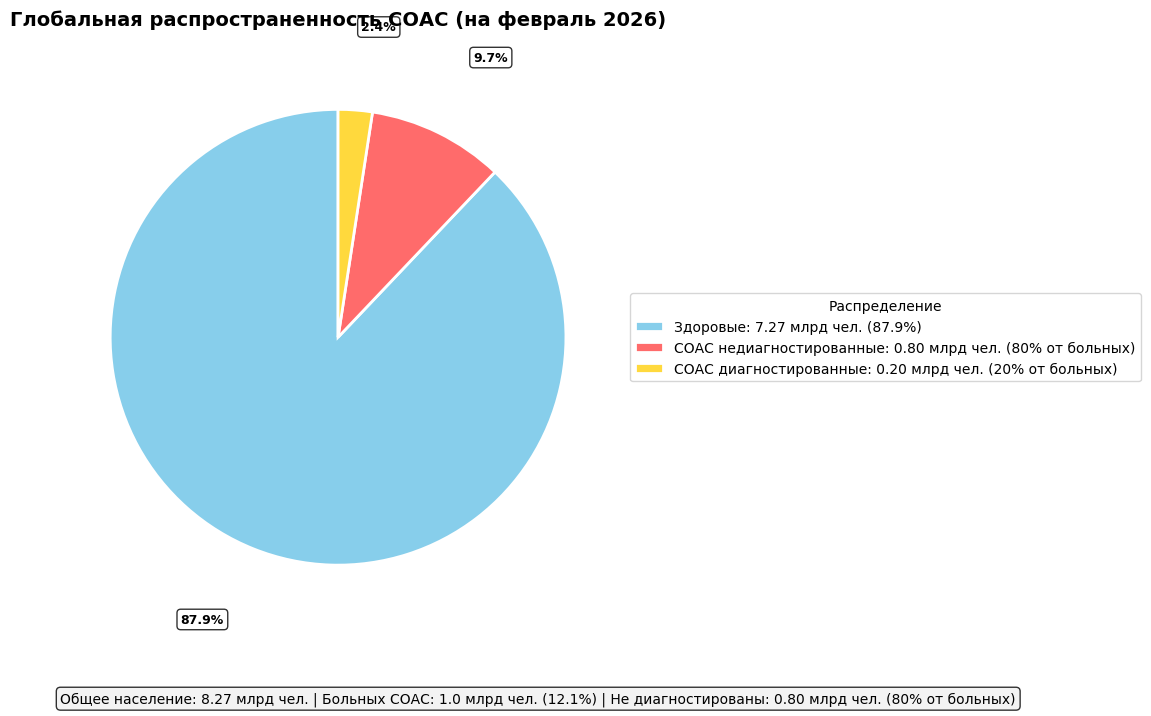

In [ ]:
import matplotlib.pyplot as plt

# Данные
total_world = 8.27  # млрд человек
total_sa = 1.0      # млрд человек с СОАС
healthy = total_world - total_sa  # здоровые

# Внутри больных: недиагностированные и диагностированные
undiagnosed_share = 0.8   # 80% от больных
diagnosed_share = 0.2     # 20% от больных

undiagnosed_abs = total_sa * undiagnosed_share
diagnosed_abs = total_sa * diagnosed_share

# Создаем фигуру
fig, ax = plt.subplots(figsize=(10, 7))

# Данные для пирога: здоровые, недиагностированные, диагностированные
sizes = [healthy, undiagnosed_abs, diagnosed_abs]
colors = ['#87CEEB', '#FF6B6B', '#FFD93D']  # небесно-голубой, коралловый, светло-желтый
labels = ['Здоровые', 'СОАС недиагностированные', 'СОАС диагностированные']

# Построение пирога
wedges, texts, autotexts = ax.pie(sizes,
                                   colors=colors,
                                   autopct='',
                                   startangle=90,
                                   wedgeprops=dict(edgecolor='white', linewidth=2))

# Создаем легенду справа с подробными подписями
legend_labels = [
    f'Здоровые: {healthy:.2f} млрд чел. ({healthy/total_world*100:.1f}%)',
    f'СОАС недиагностированные: {undiagnosed_abs:.2f} млрд чел. ({undiagnosed_share*100:.0f}% от больных)',
    f'СОАС диагностированные: {diagnosed_abs:.2f} млрд чел. ({diagnosed_share*100:.0f}% от больных)'
]

plt.legend(wedges, legend_labels,
           title="Распределение",
           loc="center left",
           bbox_to_anchor=(1, 0, 0.5, 1),
           fontsize=10)

# Добавляем проценты внутрь секторов в более компактном виде
for i, (wedge, size) in enumerate(zip(wedges, sizes)):
    ang = (wedge.theta2 + wedge.theta1) / 2
    y = np.sin(np.deg2rad(ang))
    x = np.cos(np.deg2rad(ang))

    # Процент от всего населения
    percentage = size / total_world * 100
    if i == 0:  # Здоровые
        label = f'{percentage:.1f}%'
    else:  # Больные
        label = f'{percentage:.1f}%'

    # Располагаем подпись чуть дальше от центра для лучшей читаемости
    horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
    connectionstyle = "angle,angleA=0,angleB={}".format(ang)
    plt.annotate(label, xy=(x, y), xytext=(1.35*x, 1.35*y),
                 horizontalalignment=horizontalalignment,
                 fontsize=9, weight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Заголовок
plt.title('Глобальная распространенность СОАС (на февраль 2026)',
          fontsize=14, fontweight='bold', pad=20)

# Добавляем общую информацию под графиком
plt.figtext(0.5, -0.05,
            f'Общее население: {total_world} млрд чел. | Больных СОАС: {total_sa} млрд чел. (12.1%) | '
            f'Не диагностированы: {undiagnosed_abs:.2f} млрд чел. (80% от больных)',
            ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8))

plt.tight_layout()
plt.show()